In [1]:
import networkx as nx
import pandas as pd
import numpy as np
from auxiliary_functions import *
from collections import defaultdict
import matplotlib.pyplot as plt

In [2]:
graph = nx.read_gexf("labeled_graph.gexf")
std_threshold = 0.5
NumberOfRandoms = 100

In [3]:
graphs =  simplify_graph(graph, std_threshold)

# Generate null models for each subreddit graph
null_models = {}

for subreddit, subreddit_graph in graphs.items():
	# Create multiple randomized versions of each graph for statistical comparison
	null_models[subreddit] = [
		generate_null_model(subreddit_graph) 
		for _ in range(NumberOfRandoms)
	]

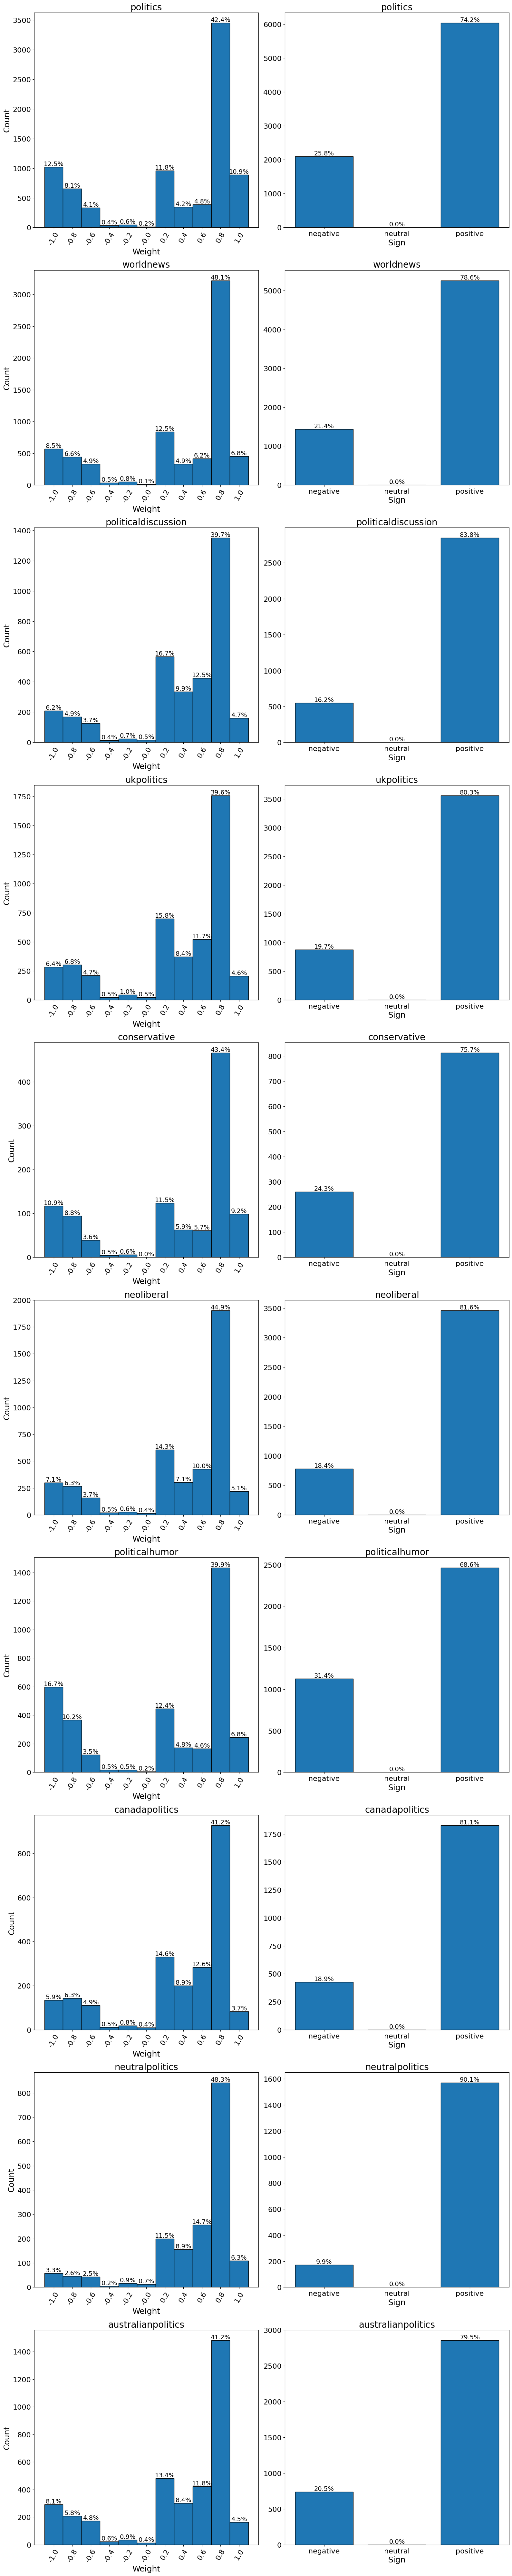

In [4]:
plot_weight_distribution(graphs)

In [5]:
triangles_graph = calculate_triangles_graph(graphs)

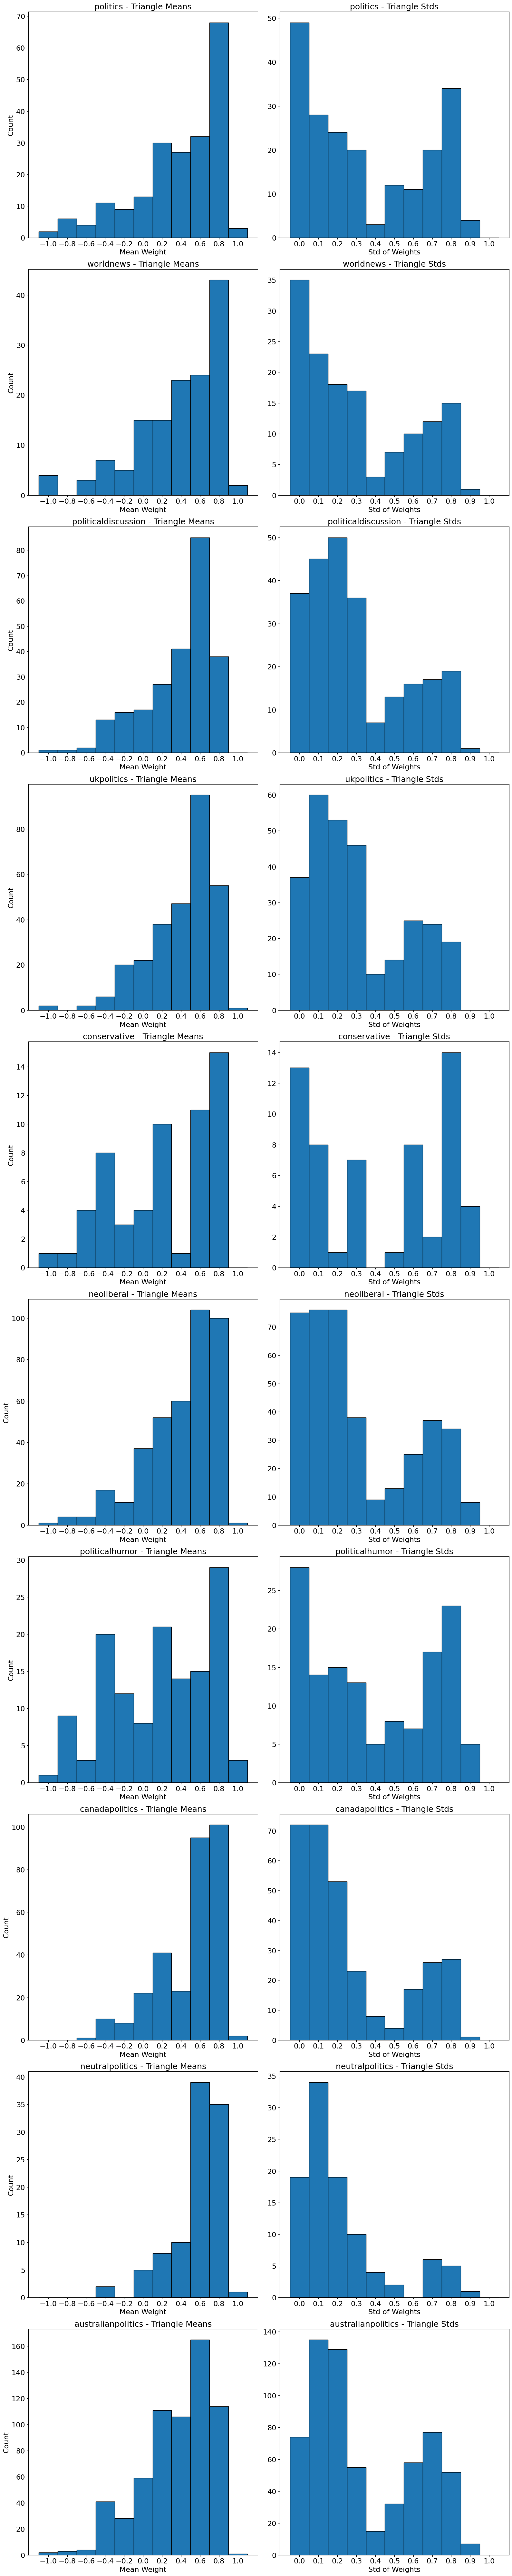

In [6]:
plot_triangle_distribution(graphs, triangles_graph)

In [7]:
df = number_of_triangles_per_type(graphs, triangles_graph)

df.to_csv('file.csv', index=True)

df

,0 pos edges,1 pos edge,2 pos edges,3 pos edges
politics,9,21,62,113
worldnews,6,10,40,85
politicaldiscussion,3,24,48,166
ukpolitics,3,24,67,194
conservative,2,14,15,27
neoliberal,6,29,100,256
politicalhumor,11,30,36,58
canadapolitics,0,16,68,219
neutralpolitics,0,3,15,82
australianpolitics,9,64,184,377


In [8]:
calculate_balance_metrics(graphs, null_models, NumberOfRandoms)

KeyboardInterrupt: 

In [ ]:
null_triangles = calculate_triangles_null_graph(graphs, null_models)

Calculated triangles for 10 subreddits with 100 null models each


In [ ]:
# IN DEVELOPMENT: NON_BINARY_METRIC

results_df = non_binary_metric(triangles_graph, null_triangles)
results_df

politics: prod=0.061540, avg_null=0.011352, ratio=5.421138083829019
worldnews: prod=0.089190, avg_null=0.023024, ratio=3.8738242624533425
politicaldiscussion: prod=0.081276, avg_null=0.027290, ratio=2.978262450555619
ukpolitics: prod=0.076475, avg_null=0.021022, ratio=3.63780402111927
conservative: prod=0.135232, avg_null=0.016074, ratio=8.412932655809522
neoliberal: prod=0.083202, avg_null=0.027169, ratio=3.062425123208641
politicalhumor: prod=0.098310, avg_null=0.002344, ratio=41.93446763911801
canadapolitics: prod=0.128910, avg_null=0.024040, ratio=5.362286599904067
neutralpolitics: prod=0.140683, avg_null=0.079729, ratio=1.7645202489770024
australianpolitics: prod=0.061621, avg_null=0.018135, ratio=3.3978553872105555


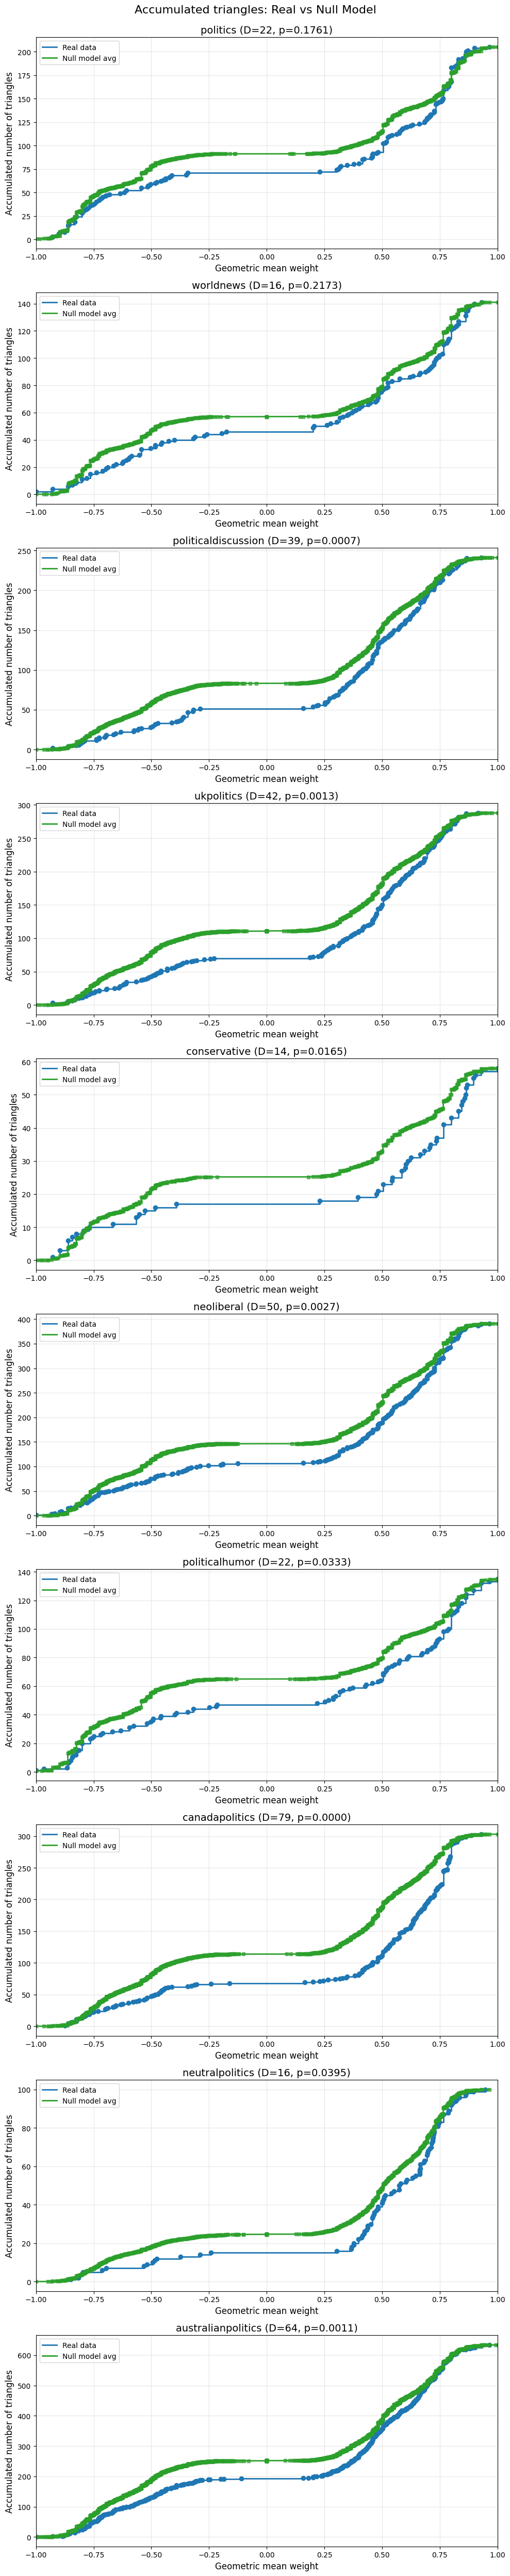


Kolmogorov-Smirnov Test Results:
politics                       | D =  22.0000 | p-value =   0.1761
worldnews                      | D =  16.0000 | p-value =   0.2173
politicaldiscussion            | D =  39.0000 | p-value =   0.0007
ukpolitics                     | D =  42.0000 | p-value =   0.0013
conservative                   | D =  14.0000 | p-value =   0.0165
neoliberal                     | D =  50.0000 | p-value =   0.0027
politicalhumor                 | D =  22.0000 | p-value =   0.0333
canadapolitics                 | D =  79.0000 | p-value =   0.0000
neutralpolitics                | D =  16.0000 | p-value =   0.0395
australianpolitics             | D =  64.0000 | p-value =   0.0011


In [ ]:
kolmogorov_smirnov(triangles_graph, null_triangles)